In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import TargetEncoder, LabelEncoder
from datetime import datetime

In [2]:
# displays all columns 
pd.set_option('display.max_columns', None)

In [3]:
def calculate_age(dob):
    today = datetime.today()
    return today.year - dob.year - ((today.month, today.day) < (dob.month, dob.day))

### Calculate distance between client and merch where there card was been used

In [4]:
def haversine(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Radius of earth in kilometers. Use 3956 for miles. Determines return value units.
    km = 6371 * c
    return km


In [5]:
def data_processing(df_path):
    df = pd.read_csv(df_path)
    df.drop(df.columns[0], axis=1, inplace=True)
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['dob'] = pd.to_datetime(df['dob'])
    
    df['year'] = df['trans_date_trans_time'].dt.year
    df['month'] = df['trans_date_trans_time'].dt.month
    df['day'] = df['trans_date_trans_time'].dt.day
    df['time'] = df['trans_date_trans_time'].dt.time
    
    df['time'] = pd.to_datetime(df.time, format='%H:%M:%S')
    
    # Ensure 'dob' is in datetime format
    df['dob'] = pd.to_datetime(df['dob'])

    # Calculate age and create a new 'age' column
    df['age'] = df['dob'].apply(calculate_age)
    
    # Calculate distance and create a new 'distance_km' column
    df['dist_client_merch'] = df.apply(lambda row: haversine(row['lat'], row['long'], row['merch_lat'], row['merch_long']), axis=1)
    
    le = LabelEncoder()
    df['le_gender'] = le.fit_transform(df['gender'])
    
    te = TargetEncoder()
    te_job = te.fit_transform(df['job'].array.reshape(-1, 1), df['is_fraud'])
    df['te_job'] = te_job
    te_street = te.fit_transform(df['street'].array.reshape(-1, 1), df['is_fraud'])
    df['te_street'] = te_street
    te_merchant = te.fit_transform(df['merchant'].array.reshape(-1, 1), df['is_fraud'])
    df['te_merchant'] = te_merchant
    te_city = te.fit_transform(df['city'].array.reshape(-1, 1), df['is_fraud'])
    df['te_city'] = te_city
    te_state = te.fit_transform(df['state'].array.reshape(-1, 1), df['is_fraud'])
    df['te_state'] = te_state
    te_category = te.fit_transform(df['category'].array.reshape(-1, 1), df['is_fraud'])
    df['te_category'] = te_category
    
    return df
    
    
    

In [6]:
df = data_processing('../fraudTrain.csv')

In [7]:
df.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,dist_client_merch,le_gender,te_job,te_street,te_merchant,te_city,te_state,te_category
432700,2019-07-13 04:11:30,30561214688470,fraud_Huels-Hahn,gas_transport,84.21,Gina,Morrison,F,41851 Victor Drives Suite 219,Allentown,PA,18103,40.5891,-75.4645,166081,"Scientist, research (maths)",1998-10-01,16c42ba8cc970ef7a5c2a1fe92dd3535,1342152690,40.347399,-74.568311,0,2019,7,13,1900-01-01 04:11:30,25,80.434035,0,0.004695,0.002995,0.004232,0.005782,0.005754,0.004854


In [23]:
columns_to_drop = [
    'merchant', 'category', 'gender', 'street', 'city', 'state', 'te_street', 'job', 'first', 'last', 'lat', 'long', 'time', 'cc_num', 'trans_date_trans_time', 'trans_num', 'merch_lat', 'merch_long', 'dob'
]

# Create a new DataFrame by dropping the specified columns
df_1 = df.drop(columns=columns_to_drop)

In [24]:
df_1.sample()

,amt,zip,city_pop,unix_time,is_fraud,year,month,day,age,dist_client_merch,le_gender,te_job,te_merchant,te_city,te_state,te_category
836434,12.27,45415,479994,1355329820,0,2019,12,12,53,75.415201,0,0.011709,0.000681,0.012652,0.006937,0.002512


In [11]:
df_1.corr()

,amt,zip,city_pop,unix_time,is_fraud,year,month,day,age,dist_client_merch,le_gender,te_job,te_street,te_merchant,te_city,te_state,te_category
amt,1.000000,0.001843,0.005818,-0.000293,0.219404,0.000842,-0.001748,0.000629,-0.009823,-0.001085,0.001034,0.041268,0.078721,0.092027,0.070014,0.007259,0.097980
zip,0.001843,1.000000,0.078467,0.000670,-0.002162,0.000086,0.000852,-0.000607,0.010419,0.006183,-0.065951,-0.007596,-0.006734,0.005129,-0.006132,-0.056480,0.005206
city_pop,0.005818,0.078467,1.000000,-0.001714,0.002136,-0.001673,0.000137,0.000159,-0.094043,0.010901,-0.028649,0.003523,0.006590,0.000462,0.006660,-0.011869,0.000593
unix_time,-0.000293,0.000670,-0.001714,1.000000,-0.005078,0.782582,0.184868,0.017162,-0.003637,-0.000633,-0.000960,-0.001686,-0.003410,0.000217,-0.003716,-0.002112,0.000180
is_fraud,0.219404,-0.002162,0.002136,-0.005078,1.000000,0.003004,-0.012409,0.003848,0.012401,0.000403,0.007642,0.170686,0.317752,0.065655,0.281026,0.036775,0.070589
year,0.000842,0.000086,-0.001673,0.782582,0.003004,1.000000,-0.464879,-0.045759,-0.004397,-0.000595,-0.000654,-0.004333,-0.000093,0.001632,0.000122,-0.001373,0.001634
month,-0.001748,0.000852,0.000137,0.184868,-0.012409,-0.464879,1.000000,0.012434,0.002212,0.000098,-0.000215,0.004508,-0.005163,-0.001355,-0.005728,-0.001129,-0.001370
day,0.000629,-0.000607,0.000159,0.017162,0.003848,-0.045759,0.012434,1.000000,0.000575,-0.000594,-0.000206,-0.000407,0.005183,0.000751,0.002751,0.003670,0.001011
age,-0.009823,0.010419,-0.094043,-0.003637,0.012401,-0.004397,0.002212,0.000575,1.000000,-0.004614,0.007353,0.031958,0.038527,-0.000893,0.034428,0.019320,-0.001428
dist_client_merch,-0.001085,0.006183,0.010901,-0.000633,0.000403,-0.000595,0.000098,-0.000594,-0.004614,1.000000,-0.002394,0.000883,0.000028,0.000763,-0.000093,-0.005233,0.001072


In [25]:
df_test = data_processing('../fraudTest.csv')

In [26]:
df_2 = df_test.drop(columns=columns_to_drop)

In [27]:
df_2.sample()

,amt,zip,city_pop,unix_time,is_fraud,year,month,day,age,dist_client_merch,le_gender,te_job,te_merchant,te_city,te_state,te_category
304204,83.14,41836,798,1381698539,0,2020,10,13,98,75.731964,1,0.0,0.0,0.0,0.005076,0.001331


# Model Development

In [28]:
X = df_1.drop(columns=['is_fraud'])  # Features
y = df_1['is_fraud'] 

In [29]:
X_test_actual = df_2.drop(columns=['is_fraud'])  # Features
y_test_actual = df_2['is_fraud'] 

## Data Split

In [15]:
from sklearn.model_selection import train_test_split


In [ ]:
X_train_unbalanced, X_test_unbalanced, y_train_unbalanced, y_test_unbalanced = train_test_split(X, y, test_size=0.2, random_state=40)


In [ ]:
print("X_train_unbalanced shape:", X_train_unbalanced.shape)
print("X_test_unbalanced shape:", X_test_unbalanced.shape)
print("y_train_unbalanced shape:", y_train_unbalanced.shape)
print("y_test_unbalanced shape:", y_test_unbalanced.shape)

In [16]:
from sklearn import metrics
import matplotlib.pyplot as plt

# Define a function to measure various metrics
def measure_metrics(y_test, y_pred, y_prob=None):
    # Print accuracy score
    print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
    
    # Plot confusion matrix
    disp = metrics.ConfusionMatrixDisplay(metrics.confusion_matrix(y_test, y_pred))
    disp.plot()
    
    # Print classification report
    print(metrics.classification_report(y_test, y_pred))
    
    if y_prob is not None:
        # Calculate ROC AUC score
        roc_auc = metrics.roc_auc_score(y_test, y_prob)
        print("ROC AUC Score:", roc_auc)
        
        # Plot ROC curve
        fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic')
        plt.legend(loc="lower right")
        plt.show()
    else:
        print("ROC AUC and curve cannot be calculated without probability scores (y_prob).")

# Example usage
# Assuming y_test, y_pred, and y_prob are defined
# measure_metrics(y_test, y_pred, y_prob)


## Model without balancing

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [30]:
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
svm = SVC()
dt = DecisionTreeClassifier()

In [31]:
dt.fit(X, y)


DecisionTreeClassifier()

In [32]:
y_pred_dt = dt.predict(X_test_actual)
y_prob_dt = dt.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9202132732550083
              precision    recall  f1-score   support

           0       1.00      0.92      0.96    553574
           1       0.01      0.30      0.03      2145

    accuracy                           0.92    555719
   macro avg       0.51      0.61      0.49    555719
weighted avg       0.99      0.92      0.95    555719

ROC AUC Score: 0.6132819188432349


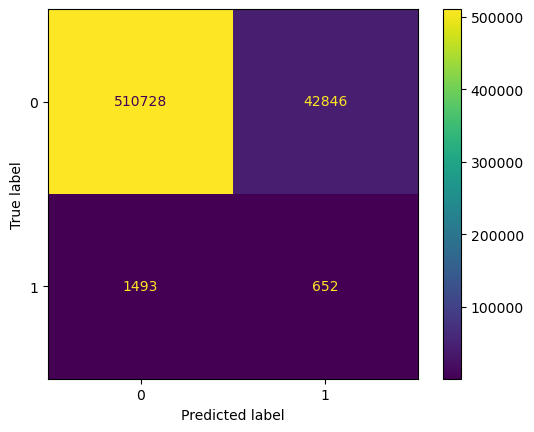

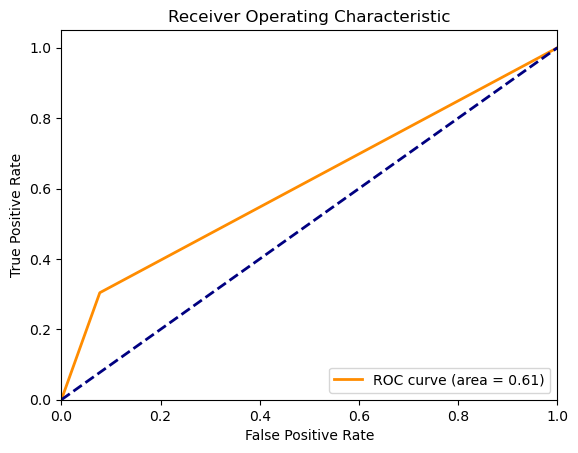

In [33]:
measure_metrics(y_test_actual, y_pred_dt, y_prob_dt)

## Model with balancing

In [34]:
from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Resample the dataset
X_train_smote, y_train_smote = smote.fit_resample(X, y)

In [36]:
rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier()

In [37]:
y_pred_rf_smote = rf.predict(X_test_actual)
y_prob_rf_smote = rf.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9676905054532956
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    553574
           1       0.06      0.52      0.11      2145

    accuracy                           0.97    555719
   macro avg       0.53      0.75      0.55    555719
weighted avg       0.99      0.97      0.98    555719

ROC AUC Score: 0.9010855199444259


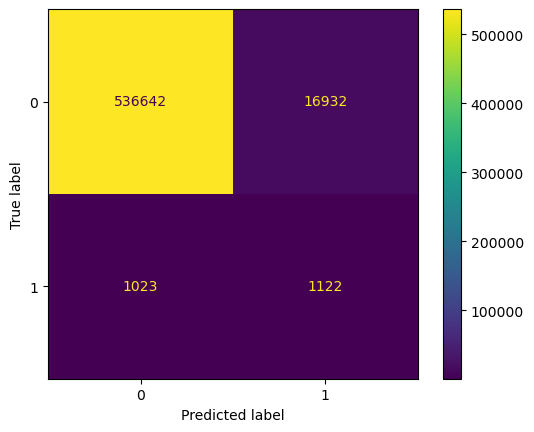

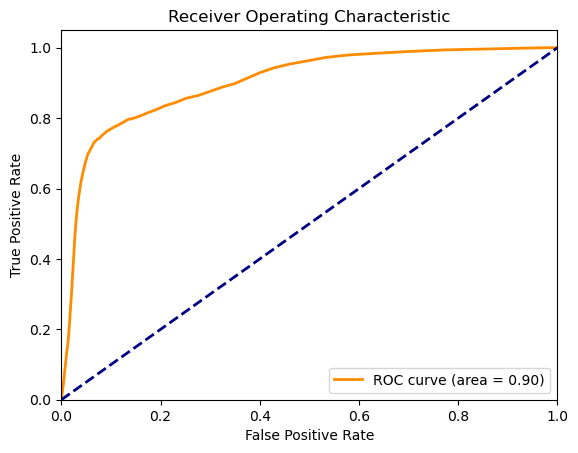

In [38]:
measure_metrics(y_test_actual, y_pred_rf_smote, y_prob_rf_smote)

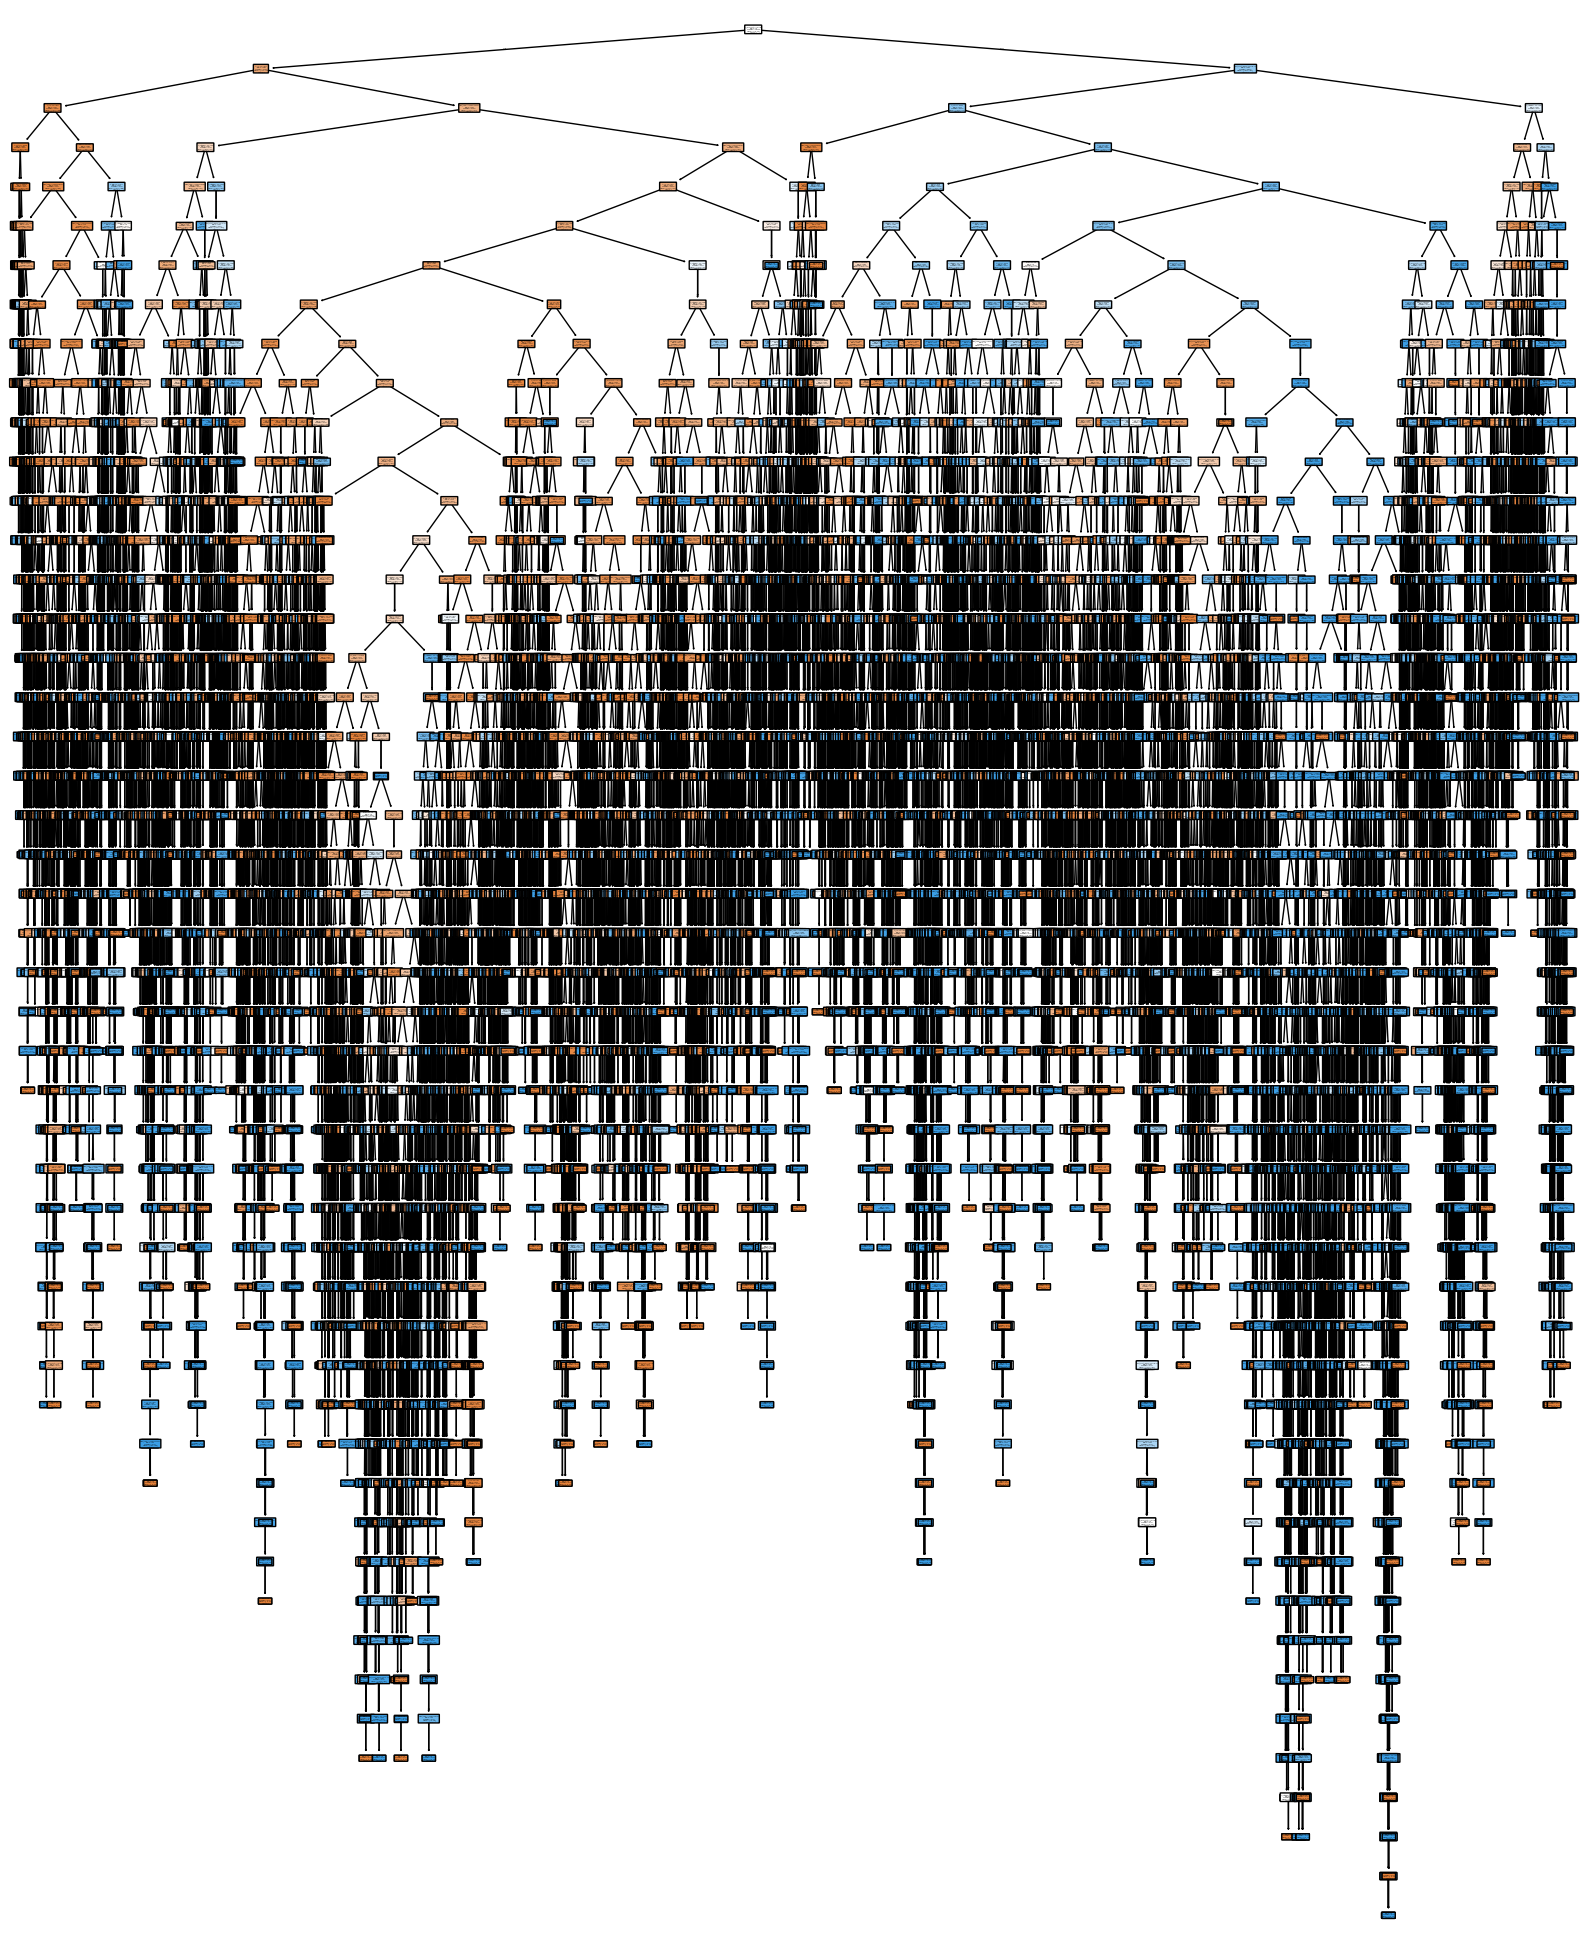

In [40]:
import matplotlib.pyplot as plt
from sklearn import tree

# Assuming `rf` is your trained RandomForestClassifier model

# Extract one tree from the random forest
single_tree = rf.estimators_[0]

# Plot the tree
plt.figure(figsize=(20, 25))
tree.plot_tree(
    single_tree,
    feature_names=X_train_smote.columns,  # Replace with your actual feature names
    class_names=['1', '0'],
    rounded=True,  # Rounded node edges
    filled=True,  # Adds color according to class
    proportion=True  # Proportionally size nodes
)
plt.show()
